In [25]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

import sys
sys.path.append('../src')
from utils import *
from datamodule import *

In [26]:
def load_and_reshape_data(file_path):
    """
    Reads the CSV data, infers grid dimensions, and reshapes into (C, H, W) tensors.
    """
    # 1. Load Data
    # Assuming the data is comma-separated as shown in your snippet
    df = pd.read_csv(file_path)

    # 2. Infer Grid Dimensions
    # We assume the data represents a structured grid flattened out.
    # Usually x corresponds to columns (W) and y to rows (H).
    unique_x = sorted(df['x'].unique())
    unique_y = sorted(df['y'].unique())
    unique_z = sorted(df['z'].unique())

    W = len(unique_x)
    H = len(unique_y)
    
    # Calculate grid spacing from data
    dx = unique_x[1] - unique_x[0] if W > 1 else 0.002
    dy = unique_y[1] - unique_y[0] if H > 1 else 0.002
    dz = unique_z[1] - unique_z[0] if len(unique_z) > 1 else 0.005 # Fallback to 0.005 if 2D

    # 3. Sort to ensure correct reshaping
    # Sort by y first (rows), then x (cols) to match image layout (Row-Major)
    df = df.sort_values(by=['y', 'x'])

    # 4. Construct Tensors
    # Channel Order expected by your functions:
    # Pressure Drop function expects: [Ux, Uy, Uz, p] (4 channels)
    # Continuity function expects:    [Ux, Uy, Uz]    (3 channels)

    # Model Predictions
    model_stack = np.stack([
        df['Ux'].values,
        df['Uy'].values,
        df['Uz'].values,
        df['p'].values
    ]) # Shape (4, N_points)
    
    # Ground Truth (OF)
    truth_stack = np.stack([
        df['Ux_OF'].values,
        df['Uy_OF'].values,
        df['Uz_OF'].values,
        df['p_OF'].values
    ]) # Shape (4, N_points)

    # Reshape to (C, H, W)
    # Note: We used sort_values(y, x), so reshaping to (H, W) fills row by row.
    model_tensor = torch.tensor(model_stack.reshape(4, H, W), dtype=torch.float32)
    truth_tensor = torch.tensor(truth_stack.reshape(4, H, W), dtype=torch.float32)

    return model_tensor, truth_tensor, H, W, dx, dy, dz

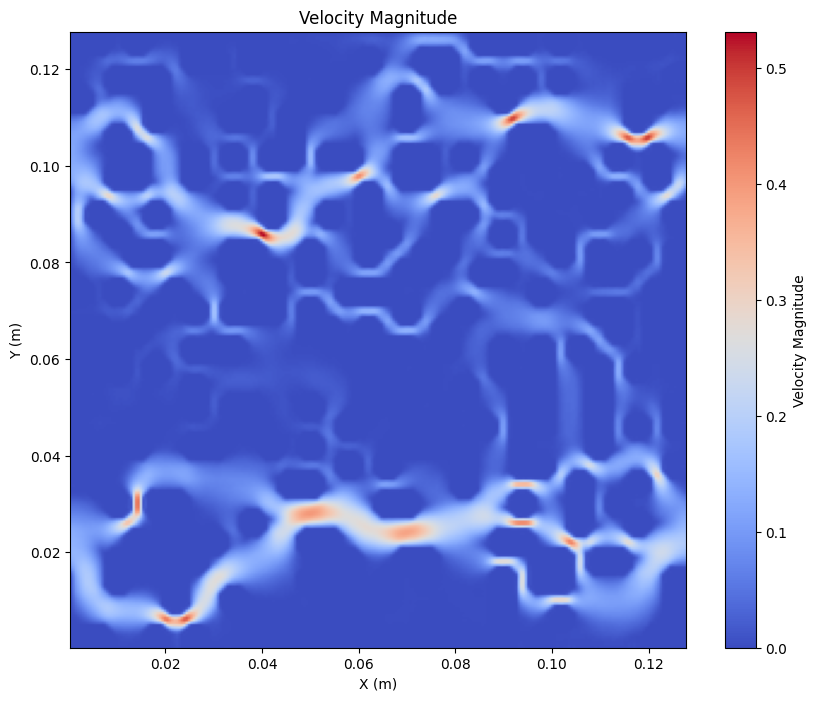

In [27]:
dim = "256"
scaling = ""
scaling_factor = int(scaling[1:]) if scaling else 1
scaling_string = '_' + scaling if scaling else ''
index = 0
directory = f'../working/tpfm_data/data_{scaling if scaling else dim}'
file_path = f'{directory}/model_output_{int(dim) * scaling_factor}{scaling_string}_{index}'

model_tensor, truth_tensor, H, W, dx, dy, dz = load_and_reshape_data(file_path)
coords_file = f'../data/coordinates_{H}.csv'

plot_velocity_magnitude(model_tensor, load_coordinates(coords_file))

In [28]:
selected_samples1 = {
    "64": [0, 1, 2],
}

selected_samples2 = {
    "64": [4],
    "64_x2": [3],
    "64_x4": [3],
}

selected_samples3 = {
    "64": [5],
    "128": [0],
    "256": [0],
}

In [29]:
def detect_inlets_outlets(file_paths, threshold=1e-4):
    """
    Detects inlet and outlet regions by finding the intersection of 
    active boundary rows across multiple samples.
    
    Returns:
        inlets (list of list of tuples): Grouped coordinates for inlets
        outlets (list of list of tuples): Grouped coordinates for outlets
    """
    # Helper to group consecutive indices (e.g. 15,16,17 -> Region 1)
    def group_indices(rows, col_idx):
        if not rows: return []
        rows = sorted(list(rows))
        regions = []
        current_group = [rows[0]]
        
        for i in range(1, len(rows)):
            if rows[i] == rows[i-1] + 1:
                current_group.append(rows[i])
            else:
                regions.append([(r, col_idx) for r in current_group])
                current_group = [rows[i]]
        regions.append([(r, col_idx) for r in current_group])
        return regions

    # 1. Initialize sets with the first sample
    # Note: We use truth_tensor (idx 1) as it has cleaner BCs than model prediction
    _, first_truth, H, W, _, _, _ = load_and_reshape_data(file_paths[0])
    
    # Channel 0 is Ux. Check magnitude or absolute value.
    # Left Boundary (Col 0), Right Boundary (Col W-1)
    ux_left = first_truth[0, :, 0]
    ux_right = first_truth[0, :, -1]
    
    # Find rows where velocity is non-zero (active inlet/outlet)
    common_inlet_rows = set(torch.where(torch.abs(ux_left) > threshold)[0].tolist())
    common_outlet_rows = set(torch.where(torch.abs(ux_right) > threshold)[0].tolist())

    # 2. Intersect with subsequent samples
    for path in file_paths[1:]:
        _, truth, _, _, _, _, _ = load_and_reshape_data(path)
        
        ux_left = truth[0, :, 0]
        ux_right = truth[0, :, -1]
        
        current_inlet_rows = set(torch.where(torch.abs(ux_left) > threshold)[0].tolist())
        current_outlet_rows = set(torch.where(torch.abs(ux_right) > threshold)[0].tolist())
        
        # Intersection: Keep only rows active in ALL samples so far
        common_inlet_rows &= current_inlet_rows
        common_outlet_rows &= current_outlet_rows

    # 3. Format into connected regions
    inlets = group_indices(common_inlet_rows, 0)
    outlets = group_indices(common_outlet_rows, W - 1)
    
    return inlets, outlets


dim = "64"
scaling = ""
scaling_factor = int(scaling[1:]) if scaling else 1
scaling_string = '_' + scaling if scaling else ''
directory = f'../working/tpfm_data/data_{scaling if scaling else dim}'
file_paths = [f'{directory}/model_output_{int(dim) * scaling_factor}{scaling_string}_{index}' for index in range(10)]

inlets, outlets = detect_inlets_outlets(file_paths)
print("Inlets:", inlets)
print("Outlets:", outlets)

Inlets: [[(10, 0), (11, 0), (12, 0), (13, 0)], [(50, 0), (51, 0), (52, 0), (53, 0)]]
Outlets: [[(10, 63), (11, 63), (12, 63), (13, 63)], [(50, 63), (51, 63), (52, 63), (53, 63)]]


In [30]:
def continuity_violation_field_vec(model_output, x_grid_spacing=0.002, y_grid_spacing=0.002, z_grid_spacing=0.005):
    """
    Vectorized version of continuity_violation_field, preserving inward-pointing normals and areas.
    """
    if model_output.ndim == 4:
        model_output = model_output[0]  # take first in batch
    H, W = model_output.shape[1], model_output.shape[2]

    # Neighboring cells
    vel = model_output[:3]  # Ux, Uy, Uz
    left = vel[:, 1:-1, :-2]
    right = vel[:, 1:-1, 2:]
    bottom = vel[:, :-2, 1:-1]
    top = vel[:, 2:, 1:-1]

    # Normals (inward-pointing)
    device = model_output.device
    normal_top = torch.tensor([0, -1, 0], dtype=model_output.dtype, device=device)
    normal_bottom = torch.tensor([0, 1, 0], dtype=model_output.dtype, device=device)
    normal_left = torch.tensor([1, 0, 0], dtype=model_output.dtype, device=device)
    normal_right = torch.tensor([-1, 0, 0], dtype=model_output.dtype, device=device)

    area_x = x_grid_spacing * z_grid_spacing
    area_y = y_grid_spacing * z_grid_spacing

    # Fluxes: dot product along channel axis (0)
    top_flux = torch.einsum('c, cxy -> xy', normal_top, top) * area_x
    bottom_flux = torch.einsum('c, cxy -> xy', normal_bottom, bottom) * area_x
    left_flux = torch.einsum('c, cxy -> xy', normal_left, left) * area_y
    right_flux = torch.einsum('c, cxy -> xy', normal_right, right) * area_y

    divergence = top_flux + bottom_flux + left_flux + right_flux
    return divergence.unsqueeze(0)  # (1, H-2, W-2)

def pressure_drop(field, inlets, outlets, scaled=False, verbose=False):
    if field.ndim == 4:
        field = field[0]  # take first in batch
    p = field[3]  # (H, W)
    H, W = p.shape

    # Take mean pressure on each inlet
    p_inlets = []
    for region in inlets:
        vals = [p[r, c].item() for (r, c) in region]
        p_inlets.append(np.mean(vals))

    # Outlets: average over both regions (boundary condition p≈0, but we compute anyway)
    p_outlets = []
    for region in outlets:
        vals = [p[r, c].item() for (r, c) in region]
        p_outlets.append(np.mean(vals))

    p_outlet = np.mean(p_outlets)  # or 0 if BC fixes it

    if scaled:
        u = 0.1
        dZ = 0.005
        dX = 0.002
        S = dX * dZ
        flow = u * S * sum(len(region) for region in inlets)  # total flow rate
    else:
        flow = 1.0

    if verbose:
        print(f"max inlet pressure: {max(p_inlets)}, outlet pressure: {p_outlet}, flow: {flow}")

    return (max(p_inlets) - p_outlet) / flow  # Δp / Q

In [31]:
def tv_loss(pred):
    # Maybe penalize only for pressure channel (assumed to be channel index 3)
    # p = pred[:, 3:4, :, :]
    p = pred
    dx = p[:, :, 1:, :] - p[:, :, :-1, :]
    dy = p[:, :, :, 1:] - p[:, :, :, :-1]
    return dx.abs().mean() + dy.abs().mean()

def loss_fn(pred, target, tv_weight=0.1):
    mse = torch.nn.MSELoss()(pred, target).item()
    tv = tv_weight * tv_loss(pred)
    return mse + tv

In [32]:
def compute_metrics_for_sample(file_path, inlets, outlets, normalizer):
    model_tensor, truth_tensor, H, W, dx, dy, dz = load_and_reshape_data(file_path)
    
    # Continuity Violation
    cont_violation_model = continuity_violation_field_vec(model_tensor, dx, dy, dz)
    cont_violation_truth = continuity_violation_field_vec(truth_tensor, dx, dy, dz)
    
    cont_error_field = cont_violation_model - cont_violation_truth
    cont_error_global_model = torch.sum(cont_error_field).item()
    cont_error_global_truth = torch.sum(cont_violation_truth).item()
    cont_error_global_rel = cont_error_global_model / cont_error_global_truth if cont_error_global_truth != 0 else float('inf')
    
    cont_error_abs_mean_model = torch.mean(torch.abs(cont_error_field)).item()
    cont_error_abs_mean_truth = torch.mean(torch.abs(cont_violation_truth)).item()
    
    cont_error_abs_mean_rel = cont_error_abs_mean_model / cont_error_abs_mean_truth if cont_error_abs_mean_truth != 0 else float('inf')
    
    # Pressure Drop
    p_drop_model = pressure_drop(model_tensor, inlets, outlets, scaled=False)
    p_drop_truth = pressure_drop(truth_tensor, inlets, outlets, scaled=False)
    p_drop_error = (p_drop_model - p_drop_truth).item()
    p_drop_error_rel = (p_drop_error / p_drop_truth).item() if p_drop_truth != 0 else float('inf')
    
    # Losses on normalized data
    model_tensor_norm = normalizer.transform(model_tensor)
    truth_tensor_norm = normalizer.transform(truth_tensor)
    mse = torch.nn.MSELoss()(model_tensor_norm, truth_tensor_norm).item()
    tv = tv_loss(model_tensor_norm).item()
    total_loss = loss_fn(model_tensor_norm, truth_tensor_norm).item()
    
    # Losses separately for velocity and pressure
    mse_velocity = torch.nn.MSELoss()(model_tensor_norm[:, :3, :, :], truth_tensor_norm[:, :3, :, :]).item()
    mse_pressure = torch.nn.MSELoss()(model_tensor_norm[:, 3:4, :, :], truth_tensor_norm[:, 3:4, :, :]).item()
    tv_velocity = tv_loss(model_tensor_norm[:, :3, :, :]).item()
    tv_pressure = tv_loss(model_tensor_norm[:, 3:4, :, :]).item()
    total_loss_velocity = loss_fn(model_tensor_norm[:, :3, :, :], truth_tensor_norm[:, :3, :, :]).item()
    total_loss_pressure = loss_fn(model_tensor_norm[:, 3:4, :, :], truth_tensor_norm[:, 3:4, :, :]).item()
    
    return {
        "cont_error_global_model": cont_error_global_model,
        "cont_error_global_truth": cont_error_global_truth,
        "cont_error_global_rel": cont_error_global_rel,
        "cont_error_abs_mean_model": cont_error_abs_mean_model,
        "cont_error_abs_mean_truth": cont_error_abs_mean_truth,
        "cont_error_abs_mean_rel": cont_error_abs_mean_rel,
        "p_drop_model": p_drop_model,
        "p_drop_truth": p_drop_truth,
        "p_drop_error": p_drop_error,
        "p_drop_error_rel": p_drop_error_rel,
        "mse": mse,
        "tv": tv,
        "total_loss": total_loss,
        "mse_velocity": mse_velocity,
        "mse_pressure": mse_pressure,
        "tv_velocity": tv_velocity,
        "tv_pressure": tv_pressure,
        "total_loss_velocity": total_loss_velocity,
        "total_loss_pressure": total_loss_pressure,
    }

In [33]:
batch_size = 16
num_workers = 4
val_split = 0.2
data_file = "../data/mixer_64.npz"
max_samples = 0
normalize = True

def get_normalizer_for_dim(dim, scaling=""):
    scaling_factor = int(scaling[1:]) if scaling else 1
    datamodule = FluidFlowDataModule(data_file = f"../data/mixer_{int(dim) * scaling_factor}{('_upscaled_' + scaling) if scaling else ''}.npz",
                                     batch_size=batch_size,
                                    num_workers=num_workers,
                                    val_split=val_split,
                                    max_samples=max_samples,
                                    normalize=normalize)
    datamodule.setup()
    return datamodule.normalizer

normalizers = {
    "64": get_normalizer_for_dim("64"),
    "128": get_normalizer_for_dim("128"),
    "256": get_normalizer_for_dim("256"),
    "128_x2": get_normalizer_for_dim("64", "x2"),
    "256_x4": get_normalizer_for_dim("64", "x4"),
}
    

Dataset sizes - Train: 440, Val: 110
Dataset sizes - Train: 697, Val: 174
Dataset sizes - Train: 529, Val: 132
Dataset sizes - Train: 440, Val: 110
Dataset sizes - Train: 440, Val: 110


In [34]:
def compute_metrics_for_selected(selected_samples):
    for dim, indices in selected_samples.items():
        if '_' in dim:
            base_dim, scaling = dim.split('_')
        else:
            base_dim, scaling = dim, ""
        scaling_factor = int(scaling[1:]) if scaling else 1
        scaling_string = '_' + scaling if scaling else ''
        directory = f'../working/tpfm_data/data_{scaling if scaling else base_dim}'
        file_paths = [f'{directory}/model_output_{int(base_dim) * scaling_factor}{scaling_string}_{index}' for index in range(10)]
        inlets, outlets = detect_inlets_outlets(file_paths)
        
        all_metrics = []
        for index in indices:
            file_path = f'{directory}/model_output_{int(base_dim) * scaling_factor}{scaling_string}_{index}'
            normalizer = normalizers[f"{int(base_dim) * scaling_factor}{scaling_string}"]
            metrics = compute_metrics_for_sample(file_path, inlets, outlets, normalizer)
            all_metrics.append(metrics)
            printed_metrics = {k: f"{v:.5e}" for k, v in metrics.items()}
            print(f"Sample {index} Metrics:", printed_metrics)
            
compute_metrics_for_selected(selected_samples1)

Sample 0 Metrics: {'cont_error_global_model': '-3.64044e-06', 'cont_error_global_truth': '-2.63125e-07', 'cont_error_global_rel': '1.38354e+01', 'cont_error_abs_mean_model': '2.64649e-08', 'cont_error_abs_mean_truth': '2.02586e-08', 'cont_error_abs_mean_rel': '1.30636e+00', 'p_drop_model': '5.68908e+01', 'p_drop_truth': '4.98314e+01', 'p_drop_error': '7.05934e+00', 'p_drop_error_rel': '1.41665e-01', 'mse': '4.62208e-02', 'tv': '1.67799e-01', 'total_loss': '6.30007e-02', 'mse_velocity': '1.98008e-02', 'mse_pressure': '1.25481e-01', 'tv_velocity': '1.95389e-01', 'tv_pressure': '8.50300e-02', 'total_loss_velocity': '3.93397e-02', 'total_loss_pressure': '1.33984e-01'}
Sample 1 Metrics: {'cont_error_global_model': '4.29167e-06', 'cont_error_global_truth': '-4.60190e-07', 'cont_error_global_rel': '-9.32586e+00', 'cont_error_abs_mean_model': '2.37955e-08', 'cont_error_abs_mean_truth': '1.87742e-08', 'cont_error_abs_mean_rel': '1.26746e+00', 'p_drop_model': '4.59146e+01', 'p_drop_truth': '4.07

In [35]:
compute_metrics_for_selected(selected_samples2)

Sample 4 Metrics: {'cont_error_global_model': '2.28657e-06', 'cont_error_global_truth': '-7.31007e-07', 'cont_error_global_rel': '-3.12797e+00', 'cont_error_abs_mean_model': '1.68237e-08', 'cont_error_abs_mean_truth': '1.14081e-08', 'cont_error_abs_mean_rel': '1.47472e+00', 'p_drop_model': '3.15755e+01', 'p_drop_truth': '3.09344e+01', 'p_drop_error': '6.41080e-01', 'p_drop_error_rel': '2.07239e-02', 'mse': '4.90933e-03', 'tv': '1.18805e-01', 'total_loss': '1.67899e-02', 'mse_velocity': '4.87177e-03', 'mse_pressure': '5.02202e-03', 'tv_velocity': '1.45641e-01', 'tv_pressure': '3.82976e-02', 'total_loss_velocity': '1.94359e-02', 'total_loss_pressure': '8.85178e-03'}
Sample 3 Metrics: {'cont_error_global_model': '6.31308e-06', 'cont_error_global_truth': '-1.28733e-07', 'cont_error_global_rel': '-4.90401e+01', 'cont_error_abs_mean_model': '3.85420e-09', 'cont_error_abs_mean_truth': '7.93653e-10', 'cont_error_abs_mean_rel': '4.85627e+00', 'p_drop_model': '9.14228e+00', 'p_drop_truth': '1.08

In [36]:
compute_metrics_for_selected(selected_samples3)

Sample 5 Metrics: {'cont_error_global_model': '5.78753e-06', 'cont_error_global_truth': '-1.47764e-06', 'cont_error_global_rel': '-3.91674e+00', 'cont_error_abs_mean_model': '1.62902e-08', 'cont_error_abs_mean_truth': '1.01605e-08', 'cont_error_abs_mean_rel': '1.60329e+00', 'p_drop_model': '3.29415e+01', 'p_drop_truth': '2.70748e+01', 'p_drop_error': '5.86673e+00', 'p_drop_error_rel': '2.16686e-01', 'mse': '1.14800e-02', 'tv': '9.86520e-02', 'total_loss': '2.13452e-02', 'mse_velocity': '6.88153e-03', 'mse_pressure': '2.52756e-02', 'tv_velocity': '1.18659e-01', 'tv_pressure': '3.86316e-02', 'total_loss_velocity': '1.87474e-02', 'total_loss_pressure': '2.91387e-02'}
Sample 0 Metrics: {'cont_error_global_model': '2.55779e-06', 'cont_error_global_truth': '-7.16028e-08', 'cont_error_global_rel': '-3.57220e+01', 'cont_error_abs_mean_model': '1.25059e-08', 'cont_error_abs_mean_truth': '1.18102e-08', 'cont_error_abs_mean_rel': '1.05890e+00', 'p_drop_model': '2.46843e+02', 'p_drop_truth': '2.83